# Comparing tumor samples: differential gene expression (DGE) analysis
The analysis includes three pairwise comparisons, each specifying the *case* and *control* groups used for pseudobulk differential expression:

1. **Pdl1_wt + C57_wt vs Pdl1_cre**  
   - **Case:** `Pdl1_cre`  
   - **Control:** `Pdl1_wt`, `C57_wt`  
   Tests for gene expression differences in *Pdl1_cre* samples relative to both wild-type backgrounds combined.

2. **Pdl1_wt vs Pdl1_cre**  
   - **Case:** `Pdl1_cre`  
   - **Control:** `Pdl1_wt`  
   Focuses specifically on differences between *Pdl1_cre* and its wild-type littermate strain.

3. **Oprl1_cre vs C57_wt**  
   - **Case:** `Oprl1_cre`  
   - **Control:** `C57_wt`  
   Evaluates expression changes associated with *Oprl1_cre* relative to *C57BL/6 wild-type* controls.



In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
ad = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad = ad[ad.obs.tissue == 'tumor']
ad

View of AnnData object with n_obs × n_vars = 279424 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [3]:
to_keep = [
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031_1',
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031_0',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031_1',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031_0',
    'output-XETG00045__0059973__c57__20250725__091031_2',
    'output-XETG00045__0059973__c57__20250725__091031_1',
    'output-XETG00045__0059973__c57__20250725__091031_0',
    #'output-XETG00045__0059973__Oprl1_wt__20250725__091031_0',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_1',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_3',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031_2',
    #'output-XETG00045__0059973__Pdl1_cre__20250725__091031_0'
]
ad = ad[ad.obs.sample_id.isin(to_keep)]

## 🔍 Quick Clustering

This initial clustering is **independent of the differential gene expression (DGE)** analysis but serves as an important **sanity check**.  
By running a quick clustering on the dataset (e.g., using PCA, neighbors, and Leiden), you can verify that:

- Samples or cells group according to expected biological or experimental conditions  
- There are no major batch effects or mislabeled samples  
- The overall structure of the data makes sense before performing DGE

This step helps ensure that downstream comparisons are biologically meaningful and not driven by technical artifacts.

In [4]:
sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad,min_counts=30)
sc.pp.filter_cells(ad,min_genes=10)

/Users/christoffer/miniconda3/envs/cellcharter-env/lib/python3.12/site-packages/scanpy/preprocessing/_qc.py:145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_metrics.columns] = obs_metrics
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
ad.layers['counts'] = ad.X.copy()

In [6]:
sc.pp.normalize_total(ad, inplace=True,target_sum=100)
sc.pp.log1p(ad)

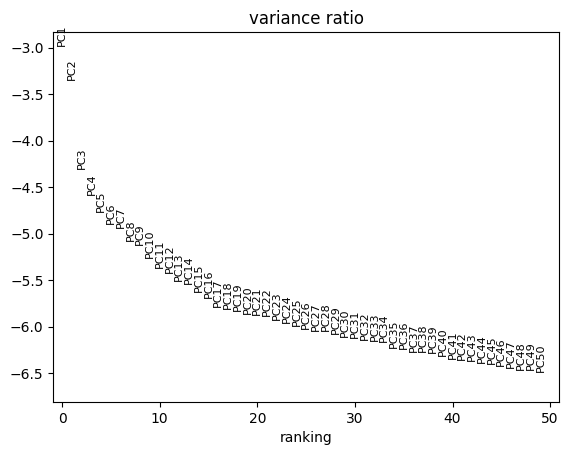

/Users/christoffer/miniconda3/envs/cellcharter-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
plt.rcdefaults()
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

In [8]:
sc.tl.umap(ad, min_dist=0.1)

clustering at resolution 0.5


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/1097621343.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))


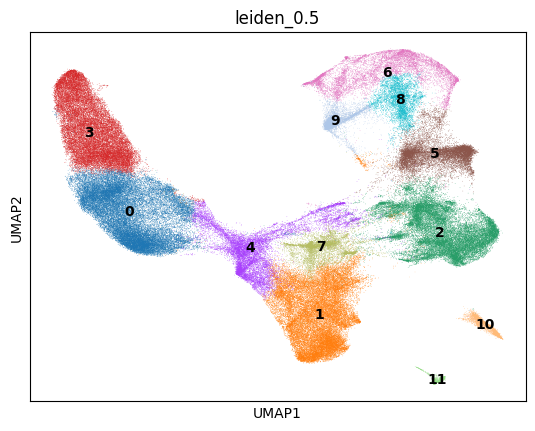

done
clustering at resolution 1


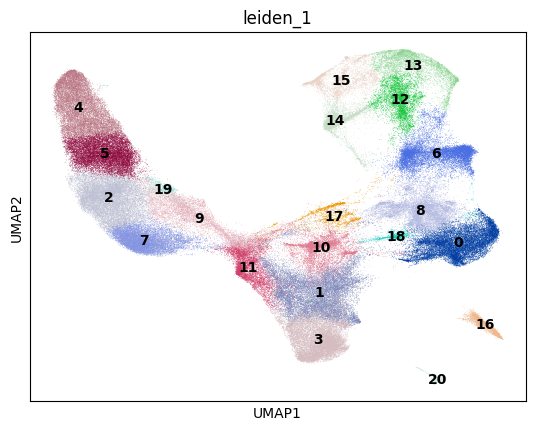

done


In [9]:
resolutions = [0.5, 1]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))
    sc.pl.umap(ad, color = 'leiden_'+str(resolution), legend_loc = 'on data')
    print("done")

## Plot spatial composition of samples

Pdl1_wt


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


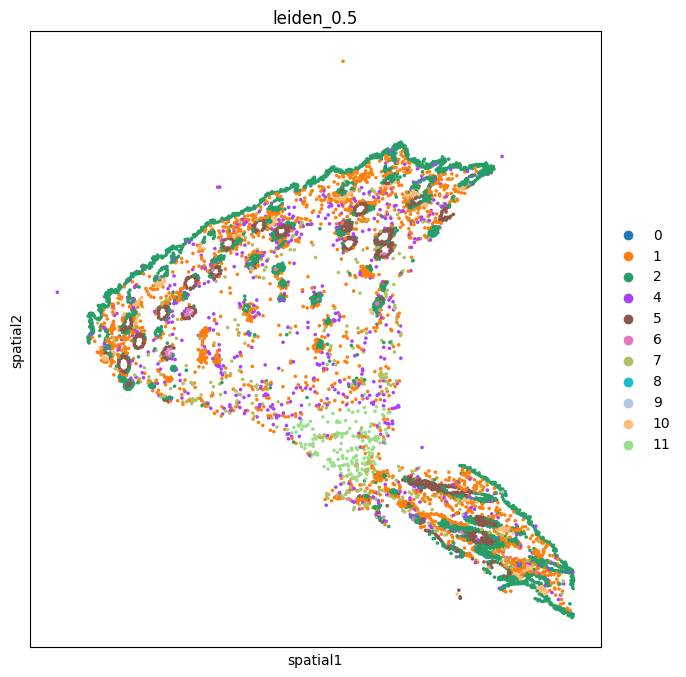

Pdl1_wt


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


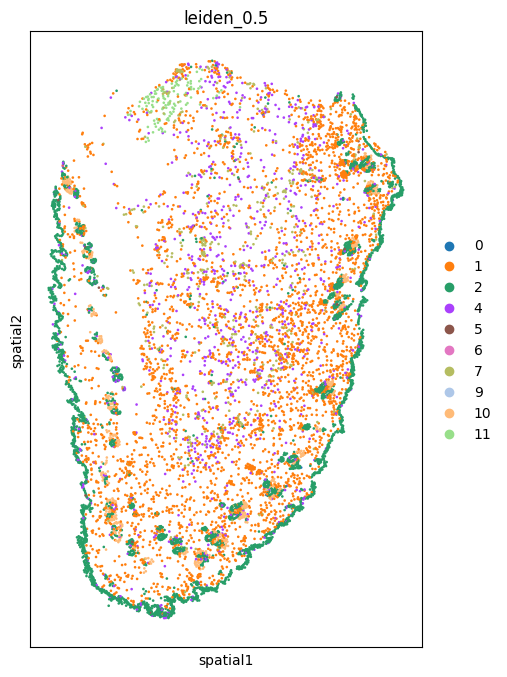

Oprl1_cre


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


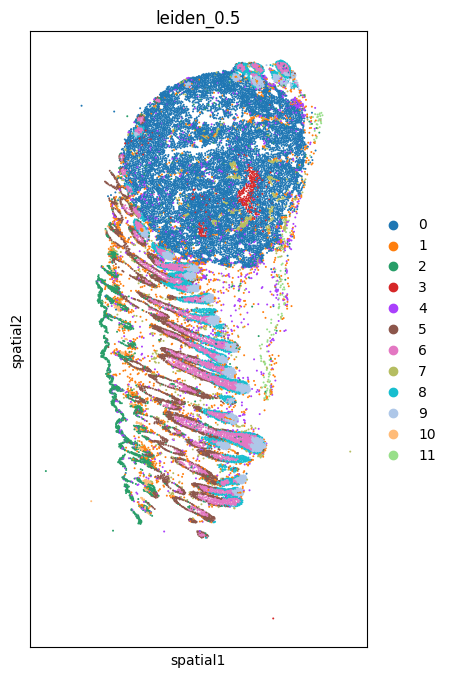

Oprl1_cre


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


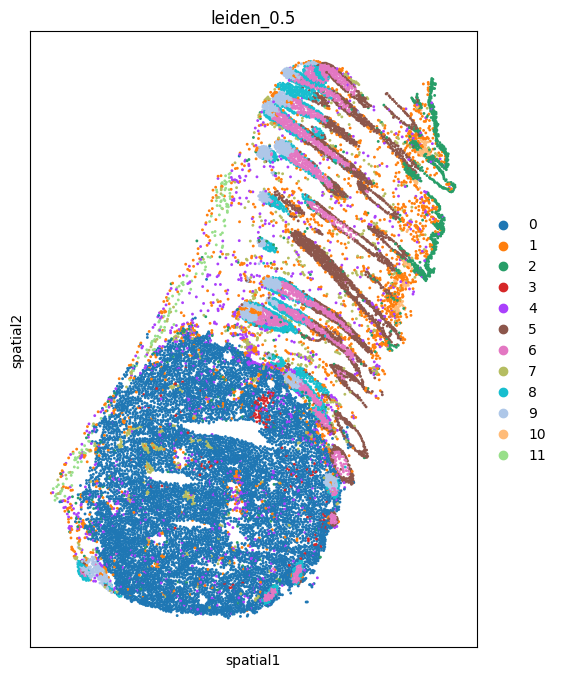

c57


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


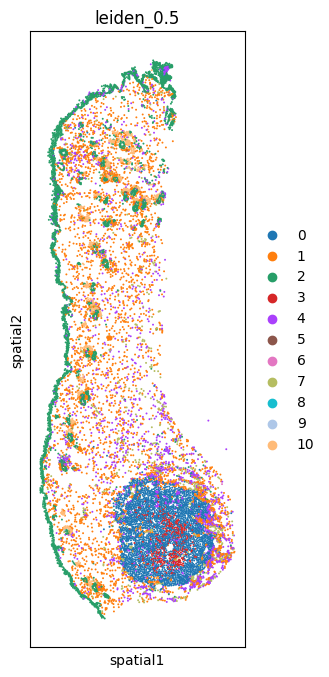

c57


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


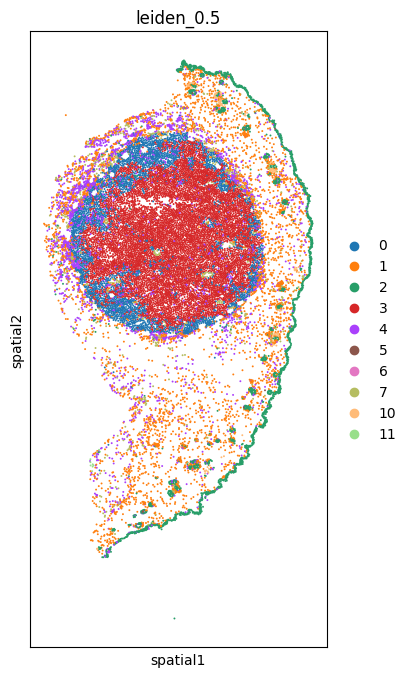

c57


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


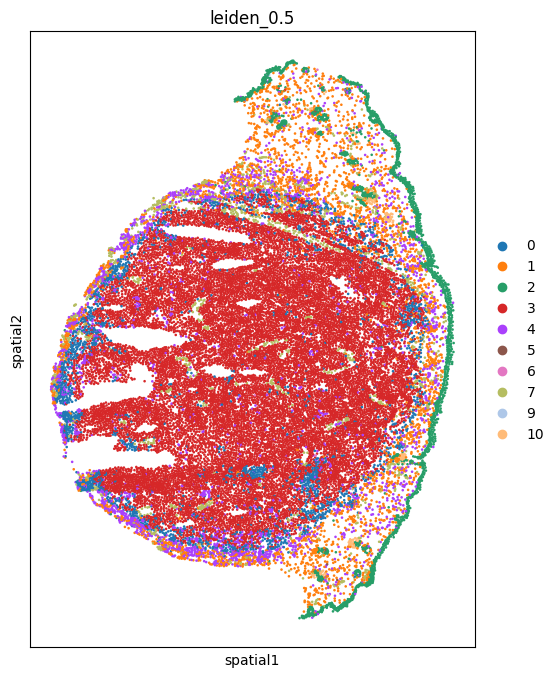

Pdl1_cre


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


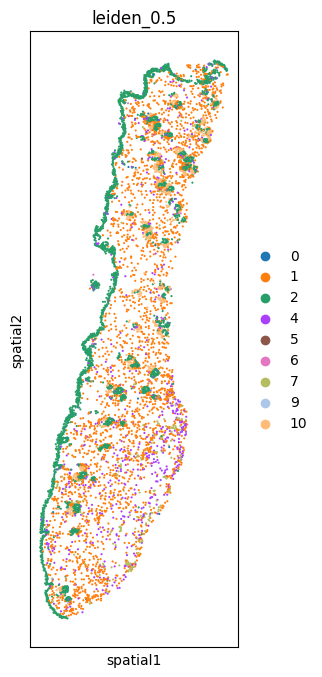

Pdl1_cre


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


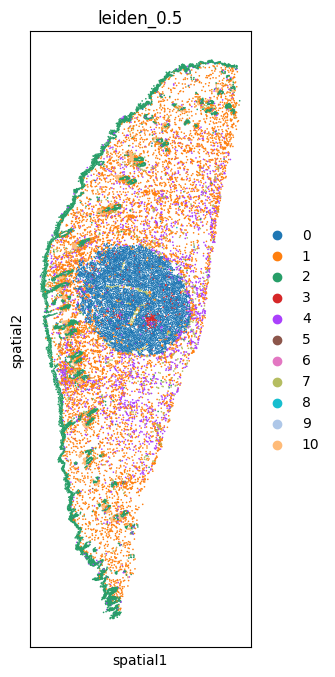

Pdl1_cre


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/2599766128.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')


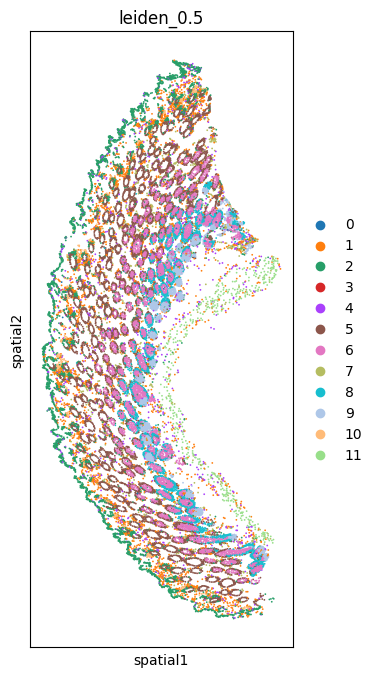

In [10]:
for grid in ad.obs['sample_id'].unique():    
    ad_int = ad[ad.obs['sample_id'] == grid]
    print(ad_int.obs.condition.unique()[0])
    with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')
    plt.show()


# Main analysis

## Specify comparisions

In [11]:
# 1) map each file prefix to a condition label
file_to_condition = {
    "output-XETG00045__0059973__Pdl1_wt__20250725__091031":  "Pdl1_wt",
    "output-XETG00045__0059973__c57__20250725__091031":      "C57_wt",
    "output-XETG00045__0059973__Pdl1_cre__20250725__091031": "Pdl1_cre",
    "output-XETG00045__0059973__Oprl1_cre__20250725__091031":"Oprl1_cre",
    "output-XETG00045__0059973__Oprl1_wt__20250725__091031": "Oprl1_wt",
}

# add condition column (sample_id should carry those prefixes)
ad.obs["condition"] = ad.obs["sample___"].map(file_to_condition)

# 2) define comparisons by condition
comparisons = {
    # 1) (Pdl1_wt + C57_wt) vs Pdl1_cre
    "Pdl1_wt+C57_vs_Pdl1_cre": {
        "case":    ["Pdl1_cre"],
        "control": ["Pdl1_wt", "C57_wt"],
    },
    # 2) Pdl1_wt vs Pdl1_cre
    "Pdl1_wt_vs_Pdl1_cre": {
        "case":    ["Pdl1_cre"],
        "control": ["Pdl1_wt"],
    },
    # 4) Oprl1_cre vs C57_wt
    "Oprl1_cre_vs_C57_wt": {
        "case":    ["Oprl1_cre"],
        "control": ["C57_wt"],
    },
}


In [12]:
import pandas as pd

# ---------- CONFIG ----------
COND_COL = "condition"
SAMPLE_COL = "sample_id"

# ---------- 1) Unique sample counts per condition ----------
sample_counts = (
    ad.obs.groupby(COND_COL)[SAMPLE_COL]
    .nunique()
    .sort_values(ascending=False)
)

print("📊 Unique samples per condition:")
for cond, n in sample_counts.items():
    print(f"  • {cond:<15} → {n} unique samples")

# ---------- 2) Map conditions → sample IDs ----------
cond_to_samples = (
    ad.obs.groupby(COND_COL)[SAMPLE_COL]
    .apply(lambda s: sorted(s.unique().tolist()))
    .to_dict()
)

print("\n🧬 Sample IDs per condition:")
for cond, sids in cond_to_samples.items():
    sid_list = ", ".join(sids)
    print(f"  • {cond:<15} ({len(sids)}) → {sid_list}")

# ---------- 3) Define condition-level comparisons ----------
comparisons = {
    "Pdl1_wt+C57_vs_Pdl1_cre": {"case": ["Pdl1_cre"], "control": ["Pdl1_wt", "C57_wt"]},
    "Pdl1_wt_vs_Pdl1_cre":     {"case": ["Pdl1_cre"], "control": ["Pdl1_wt"]},
    "Oprl1_cre_vs_C57_wt":     {"case": ["Oprl1_cre"], "control": ["C57_wt"]},
}

# ---------- 4) Expand comparisons to per-sample level ----------
def expand_comparisons_to_samples(comparisons, cond_to_samples):
    """
    Expand condition-level comparisons into sample-level groupings.
    Returns:
        dict: {comparison_name: {'case_samples': [...], 'control_samples': [...]}}
    """
    out = {}
    for name, spec in comparisons.items():
        case_conditions = spec["case"]
        ctrl_conditions = spec["control"]

        # Collect sample IDs for each group
        case_samples = sum([cond_to_samples.get(c, []) for c in case_conditions], [])
        ctrl_samples = sum([cond_to_samples.get(c, []) for c in ctrl_conditions], [])

        # Sanity checks
        overlap = set(case_samples) & set(ctrl_samples)
        if overlap:
            print(f"[WARN] Overlapping samples in {name}: {sorted(overlap)}")
        if len(case_samples) == 0 or len(ctrl_samples) == 0:
            print(f"[WARN] Empty group in {name}: case={len(case_samples)}, control={len(ctrl_samples)}")

        out[name] = {"case_samples": case_samples, "control_samples": ctrl_samples}
    return out


expanded = expand_comparisons_to_samples(comparisons, cond_to_samples)

# ---------- 5) Display expanded mapping ----------
print("\n🔍 Expanded comparisons (per-sample):")
for name, groups in expanded.items():
    print(f"\n{name}")
    print(f"  🧪 Case samples    ({len(groups['case_samples'])}):    {groups['case_samples']}")
    print(f"  🎛️ Control samples ({len(groups['control_samples'])}): {groups['control_samples']}")

📊 Unique samples per condition:
  • Pdl1_cre        → 3 unique samples
  • C57_wt          → 3 unique samples
  • Oprl1_cre       → 2 unique samples
  • Pdl1_wt         → 2 unique samples

🧬 Sample IDs per condition:
  • Oprl1_cre       (2) → output-XETG00045__0059973__Oprl1_cre__20250725__091031_0, output-XETG00045__0059973__Oprl1_cre__20250725__091031_1
  • Pdl1_cre        (3) → output-XETG00045__0059973__Pdl1_cre__20250725__091031_1, output-XETG00045__0059973__Pdl1_cre__20250725__091031_2, output-XETG00045__0059973__Pdl1_cre__20250725__091031_3
  • Pdl1_wt         (2) → output-XETG00045__0059973__Pdl1_wt__20250725__091031_0, output-XETG00045__0059973__Pdl1_wt__20250725__091031_1
  • C57_wt          (3) → output-XETG00045__0059973__c57__20250725__091031_0, output-XETG00045__0059973__c57__20250725__091031_1, output-XETG00045__0059973__c57__20250725__091031_2

🔍 Expanded comparisons (per-sample):

Pdl1_wt+C57_vs_Pdl1_cre
  🧪 Case samples    (3):    ['output-XETG00045__0059973__Pdl1_cre

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/3438939411.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad.obs.groupby(COND_COL)[SAMPLE_COL]
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/3438939411.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad.obs.groupby(COND_COL)[SAMPLE_COL]


## Save transformed data 

In [13]:
ad.layers['transformed'] = ad.X.copy()

In [14]:
ad.X = ad.layers['counts']

In [15]:
ad.X.max()

np.float32(408.0)

## Pseudobulking and differential gene expression

In [16]:
# =========================
# PSEUDOBULK + DE (from scratch)
# =========================
import numpy as np, pandas as pd
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests

# ---------- USER CONFIG ----------
COND_COL       = "condition"   # ad.obs column with condition labels
SAMPLE_COL     = "sample_id"   # ad.obs column with sample identifiers (replicates)
CELLTYPE_COL   = None          # e.g. "cell_type" to stratify; or None to pool all cells
MIN_TOTAL_COUNTS = 10          # prefilter genes: total pseudobulk counts across all samples >= this
PRIOR_COUNT      = 1.0         # logCPM prior
FDR_ALPHA        = 0.05

# Define comparisons by condition labels in ad.obs[COND_COL]
comparisons = {
    "Pdl1_wt+C57_vs_Pdl1_cre": {"case": ["Pdl1_cre"], "control": ["Pdl1_wt", "C57_wt"]},
    "Pdl1_wt_vs_Pdl1_cre":     {"case": ["Pdl1_cre"], "control": ["Pdl1_wt"]},
    "Oprl1_cre_vs_C57_wt":   {"case": ["Oprl1_cre"], "control": ["C57_wt"]},
}

# ---------- HELPERS ----------
def get_counts_and_genes(adata):
    """
    Returns (X, genes) where X is cells×genes counts and 'genes' matches X.
    Priority: layers['raw'] > layers['counts'] > ad.raw.X
    """
    if "raw" in adata.layers:
        X = adata.layers["raw"]
        genes = adata.var_names
    elif "counts" in adata.layers:
        X = adata.layers["counts"]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        raise ValueError("No counts found. Expected ad.layers['raw'] or ['counts'] or ad.raw.X.")
    return X, pd.Index(genes)

def logcpm(counts, lib_sizes=None, prior_count=1.0, scale=1e6):
    """
    Log2-CPM with prior (edgeR-style).
    counts: genes×samples dense array
    """
    if lib_sizes is None:
        lib_sizes = counts.sum(axis=0)
    lib_sizes = np.asarray(lib_sizes, dtype=float).reshape(1, -1)
    cpm = (counts * scale) / np.maximum(lib_sizes, 1.0)
    return np.log2(cpm + prior_count)

def sanitize_pvals(p):
    """Replace NaN/Inf with 1, clip into (tiny,1]."""
    p = np.asarray(p, dtype=float)
    p[~np.isfinite(p)] = 1.0
    return np.clip(p, np.finfo(float).tiny, 1.0)

# ---------- CORE: PSEUDOBULK ----------
def pseudobulk_by_sample(adata, celltype_col=None):
    """
    Returns:
      pb_counts: DataFrame [genes × samples]
      sample_meta: DataFrame with columns [group_key, sample_id, condition, (celltype?)]
    """
    X, genes = get_counts_and_genes(adata)  # cells×genes
    X = X.tocsr() if sparse.issparse(X) else np.asarray(X)

    cols = [SAMPLE_COL, COND_COL] + ([celltype_col] if celltype_col else [])
    obs = adata.obs[cols].copy()

    group_key_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    key_df = obs[group_key_cols].astype(str)
    key_df["_grp"] = key_df.apply(lambda r: "||".join(r.values.tolist()), axis=1)
    groups, inv = np.unique(key_df["_grp"].values, return_inverse=True)

    G = len(groups)
    pb = np.zeros((X.shape[1], G), dtype=np.float64)  # genes×groups
    for g in range(G):
        idx = np.where(inv == g)[0]
        if len(idx) == 0:
            continue
        if sparse.issparse(X):
            pb[:, g] = X[idx, :].sum(axis=0).A1
        else:
            pb[:, g] = X[idx, :].sum(axis=0)

    # Build sample metadata (and map condition per sample_id)
    meta_parts = [g.split("||") for g in groups]
    meta_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    sample_meta = pd.DataFrame(meta_parts, columns=meta_cols)

    cond_map = (obs.groupby(SAMPLE_COL)[COND_COL]
                  .agg(lambda s: s.unique()[0] if s.nunique()==1 else s.mode().iloc[0])
                  .to_dict())
    sample_meta[COND_COL] = sample_meta[SAMPLE_COL].map(cond_map)

    colnames = [
        f"{r[SAMPLE_COL]}" + (f"|{r[celltype_col]}" if celltype_col else "")
        for _, r in sample_meta.iterrows()
    ]
    pb_counts = pd.DataFrame(pb, index=genes, columns=colnames)
    sample_meta["group_key"] = colnames

    # Drop any all-zero columns (rare but safe)
    keep_cols = pb_counts.sum(axis=0) > 0
    if (~keep_cols).any():
        pb_counts = pb_counts.loc[:, keep_cols.values]
        sample_meta = sample_meta.loc[keep_cols.values].reset_index(drop=True)

    return pb_counts, sample_meta

# ---------- CORE: DE ----------
def run_de_welch_logcpm(logcpm_mat, sample_meta, case_conditions, ctrl_conditions):
    """
    Welch's t-test on logCPM for case vs control.
    Returns a tidy DE DataFrame indexed by gene.
    """
    sel_case = sample_meta[sample_meta[COND_COL].isin(case_conditions)]["group_key"].tolist()
    sel_ctrl = sample_meta[sample_meta[COND_COL].isin(ctrl_conditions)]["group_key"].tolist()
    n_case, n_ctrl = len(sel_case), len(sel_ctrl)
    if n_case < 2 or n_ctrl < 2:
        print(f"[WARN] Low replicate counts: case={n_case}, control={n_ctrl}. Stats will be weak.")

    Xc = logcpm_mat[sel_case].to_numpy()  # genes×n_case
    Xn = logcpm_mat[sel_ctrl].to_numpy()  # genes×n_ctrl

    mean_case = Xc.mean(axis=1)
    mean_ctrl = Xn.mean(axis=1)
    log2fc = mean_case - mean_ctrl

    t_stat, pvals = stats.ttest_ind(Xc, Xn, equal_var=False, axis=1, nan_policy="omit")
    pvals = sanitize_pvals(pvals)
    padj = multipletests(pvals, method="fdr_bh")[1]

    de = pd.DataFrame({
        "gene": logcpm_mat.index.values,
        "log2fc": log2fc,
        "pval": pvals,
        "padj": padj,
        "mean_logCPM_case": mean_case,
        "mean_logCPM_ctrl": mean_ctrl,
        "n_case_samples": n_case,
        "n_ctrl_samples": n_ctrl,
        "mode": "pseudobulk_mean",
    }).set_index("gene").sort_values(["padj","pval","log2fc"], ascending=[True,True,False])

    return de

# ---------- DRIVER ----------
def run_pseudobulk_de(adata, comparisons, celltype_col=None,
                      min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA):
    # 1) pseudobulk
    pb_counts, sample_meta = pseudobulk_by_sample(adata, celltype_col=celltype_col)

    # 2) crude prefilter BEFORE logCPM
    if min_total_counts is not None and min_total_counts > 0:
        keep = (pb_counts.sum(axis=1) >= min_total_counts)
        pb_counts = pb_counts.loc[keep]

    # 3) logCPM
    lib_sizes = pb_counts.sum(axis=0).values
    logcpm_mat = pd.DataFrame(
        logcpm(pb_counts.values, lib_sizes=lib_sizes, prior_count=prior_count, scale=1e6),
        index=pb_counts.index, columns=pb_counts.columns
    )

    # 4) DE per comparison
    results = {}
    for name, spec in comparisons.items():
        de = run_de_welch_logcpm(logcpm_mat, sample_meta, spec["case"], spec["control"])
        results[name] = de
        # quick summary
        sig = (de["padj"] <= alpha).sum()
        print(f"\n=== {name} ===")
        print(f"tested genes: {de.shape[0]} | significant @ FDR≤{alpha}: {sig}")
        print(de.head(10)[["log2fc","pval","padj","n_case_samples","n_ctrl_samples"]])

    return results, pb_counts, sample_meta, logcpm_mat

# ----------------- RUN -----------------
results, pb_counts, sample_meta, logcpm_mat = run_pseudobulk_de(
    ad, comparisons, celltype_col=CELLTYPE_COL,
    min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA
)



=== Pdl1_wt+C57_vs_Pdl1_cre ===
tested genes: 4934 | significant @ FDR≤0.05: 0
           log2fc      pval      padj  n_case_samples  n_ctrl_samples
gene                                                                 
Tubb1    0.792672  0.001139  0.938195               3               5
Grm2     1.157414  0.001188  0.938195               3               5
Acss1   -0.777115  0.001412  0.938195               3               5
Grk2    -0.390584  0.001799  0.938195               3               5
Pou6f1  -1.191725  0.002611  0.938195               3               5
Adipor1 -0.421494  0.002966  0.938195               3               5
Mpl      0.743518  0.002973  0.938195               3               5
Stimate -0.760863  0.003267  0.938195               3               5
Limd1   -0.425356  0.003471  0.938195               3               5
Smap1    0.138063  0.003504  0.938195               3               5

=== Pdl1_wt_vs_Pdl1_cre ===
tested genes: 4934 | significant @ FDR≤0.05: 0
    

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_2574/686460097.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cond_map = (obs.groupby(SAMPLE_COL)[COND_COL]


In [17]:
results

{'Pdl1_wt+C57_vs_Pdl1_cre':           log2fc      pval      padj  mean_logCPM_case  mean_logCPM_ctrl  \
 gene                                                                       
 Tubb1   0.792672  0.001139  0.938195          1.054715          0.262043   
 Grm2    1.157414  0.001188  0.938195          1.555567          0.398153   
 Acss1  -0.777115  0.001412  0.938195          5.570452          6.347567   
 Grk2   -0.390584  0.001799  0.938195          9.229231          9.619815   
 Pou6f1 -1.191725  0.002611  0.938195          5.381221          6.572946   
 ...          ...       ...       ...               ...               ...   
 Foxd3  -0.001725  0.997743  0.998553          1.213068          1.214793   
 Mcm2    0.002749  0.997998  0.998605          8.171403          8.168654   
 Chd4   -0.000994  0.998503  0.998908         11.040535         11.041529   
 Gdpd1  -0.000448  0.998973  0.999175          5.462792          5.463240   
 Nr6a1   0.000097  0.999836  0.999836          4.

In [18]:
combined_results = pd.concat(results, names=["comparison"])


In [19]:
combined_results

log2fc      pval      padj  \
comparison              gene                                    
Pdl1_wt+C57_vs_Pdl1_cre Tubb1    0.792672  0.001139  0.938195   
                        Grm2     1.157414  0.001188  0.938195   
                        Acss1   -0.777115  0.001412  0.938195   
                        Grk2    -0.390584  0.001799  0.938195   
                        Pou6f1  -1.191725  0.002611  0.938195   
...                                   ...       ...       ...   
Oprl1_cre_vs_C57_wt     Dmrt2    0.001319  0.997885  0.998521   
                        Bmp10   -0.000327  0.997914  0.998521   
                        Pkd2     0.000109  0.998619  0.999024   
                        Ern2    -0.000522  0.999277  0.999479   
                        Tmem108  0.000074  0.999693  0.999693   

                                 mean_logCPM_case  mean_logCPM_ctrl  \
comparison              gene                                          
Pdl1_wt+C57_vs_Pdl1_cre Tubb1            1.054715          0.262043   
                        Grm2             1.555567          0.398153   
                        Acss1            5.570452          6.347567   
                        Grk2             9.229231          9.619815   
                        Pou6f1           5.381221          6.572946   
...                                           ...               ...   
Oprl1_cre_vs_C57_wt     Dmrt2            1.144587          1.143269   
                        Bmp10            0.238719          0.239047   
                        Pkd2             7.707689          7.707580   
                        Ern2             1.139768          1.140290   
                        Tmem108          0.229027          0.228953   

                                 n_case_samples  n_ctrl_samples  \
comparison              gene                                      
Pdl1_wt+C57_vs_Pdl1_cre Tubb1                 3               5   
                        Grm2                  3               5   
                        Acss1                 3               5   
                        Grk2                  3               5   
                        Pou6f1                3               5   
...                                         ...             ...   
Oprl1_cre_vs_C57_wt     Dmrt2                 2               3   
                        Bmp10                 2               3   
                        Pkd2                  2               3   
                        Ern2                  2               3   
                        Tmem108               2               3   

                                            mode  
comparison              gene                      
Pdl1_wt+C57_vs_Pdl1_cre Tubb1    pseudobulk_mean  
                        Grm2     pseudobulk_mean  
                        Acss1    pseudobulk_mean  
                        Grk2     pseudobulk_mean  
                        Pou6f1   pseudobulk_mean  
...                                          ...  
Oprl1_cre_vs_C57_wt     Dmrt2    pseudobulk_mean  
                        Bmp10    pseudobulk_mean  
                        Pkd2     pseudobulk_mean  
                        Ern2     pseudobulk_mean  
                        Tmem108  pseudobulk_mean  

[14802 rows x 8 columns]

In [20]:
combined_results = pd.concat(results, names=["comparison"])
combined_results = combined_results.reset_index(level="comparison").reset_index()

In [21]:
combined_results

,gene,comparison,log2fc,pval,padj,mean_logCPM_case,mean_logCPM_ctrl,n_case_samples,n_ctrl_samples,mode
0,Tubb1,Pdl1_wt+C57_vs_Pdl1_cre,0.792672,0.001139,0.938195,1.054715,0.262043,3,5,pseudobulk_mean
1,Grm2,Pdl1_wt+C57_vs_Pdl1_cre,1.157414,0.001188,0.938195,1.555567,0.398153,3,5,pseudobulk_mean
2,Acss1,Pdl1_wt+C57_vs_Pdl1_cre,-0.777115,0.001412,0.938195,5.570452,6.347567,3,5,pseudobulk_mean
3,Grk2,Pdl1_wt+C57_vs_Pdl1_cre,-0.390584,0.001799,0.938195,9.229231,9.619815,3,5,pseudobulk_mean
4,Pou6f1,Pdl1_wt+C57_vs_Pdl1_cre,-1.191725,0.002611,0.938195,5.381221,6.572946,3,5,pseudobulk_mean
...,...,...,...,...,...,...,...,...,...,...
14797,Dmrt2,Oprl1_cre_vs_C57_wt,0.001319,0.997885,0.998521,1.144587,1.143269,2,3,pseudobulk_mean
14798,Bmp10,Oprl1_cre_vs_C57_wt,-0.000327,0.997914,0.998521,0.238719,0.239047,2,3,pseudobulk_mean
14799,Pkd2,Oprl1_cre_vs_C57_wt,0.000109,0.998619,0.999024,7.707689,7.707580,2,3,pseudobulk_mean
14800,Ern2,Oprl1_cre_vs_C57_wt,-0.000522,0.999277,0.999479,1.139768,1.140290,2,3,pseudobulk_mean


## Export data for customer

In [22]:
combined_results.to_csv('../../results/differential-gene-expression/tumor/pseudobulk_comparision.csv')

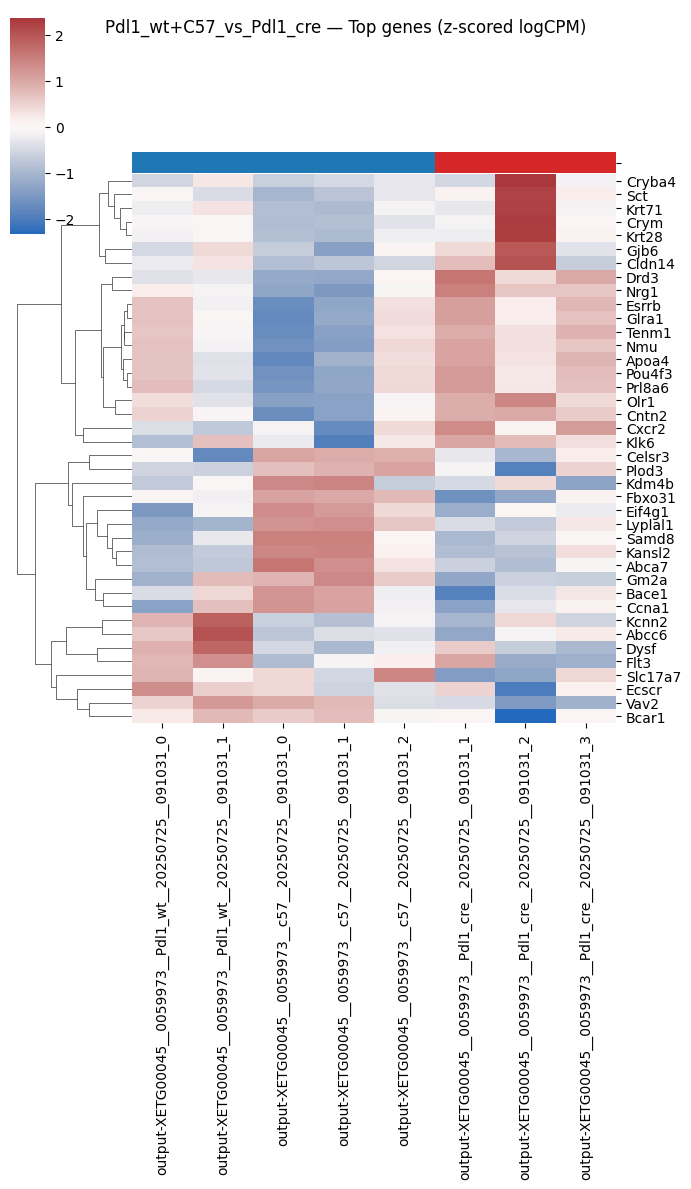

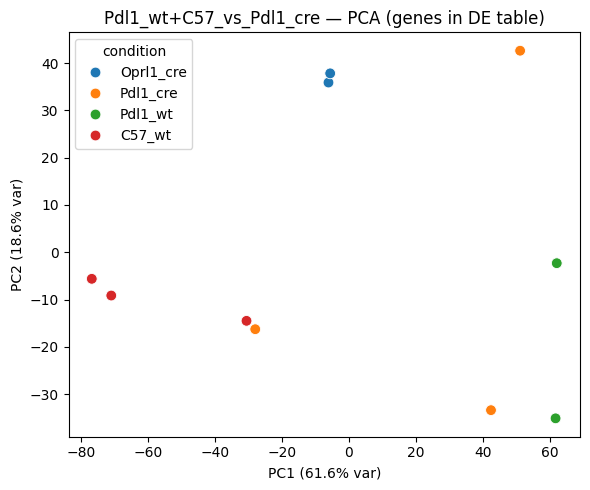

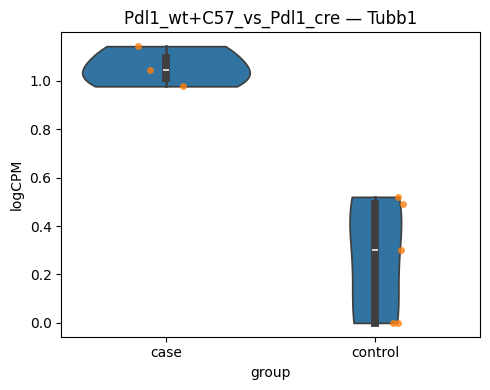

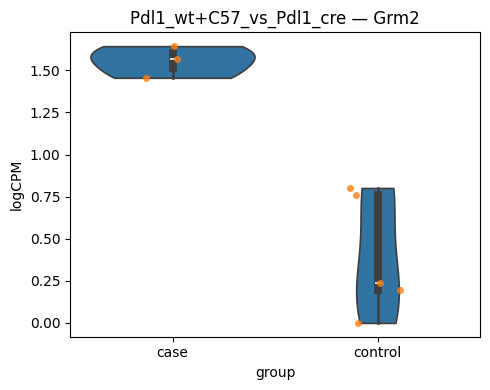

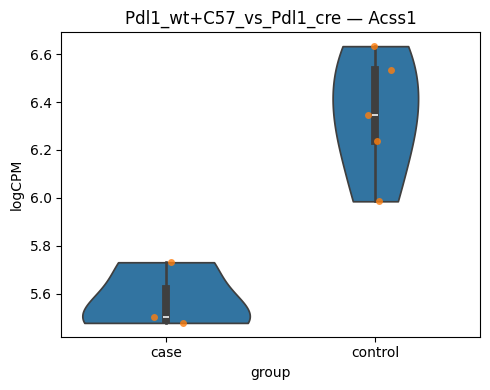

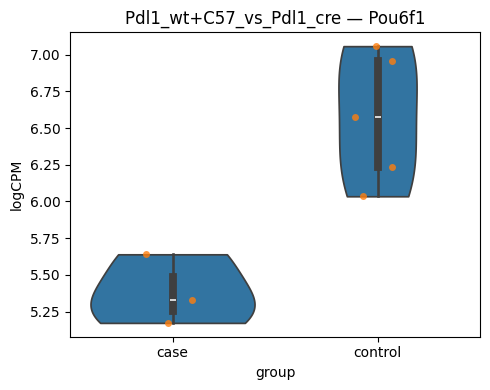

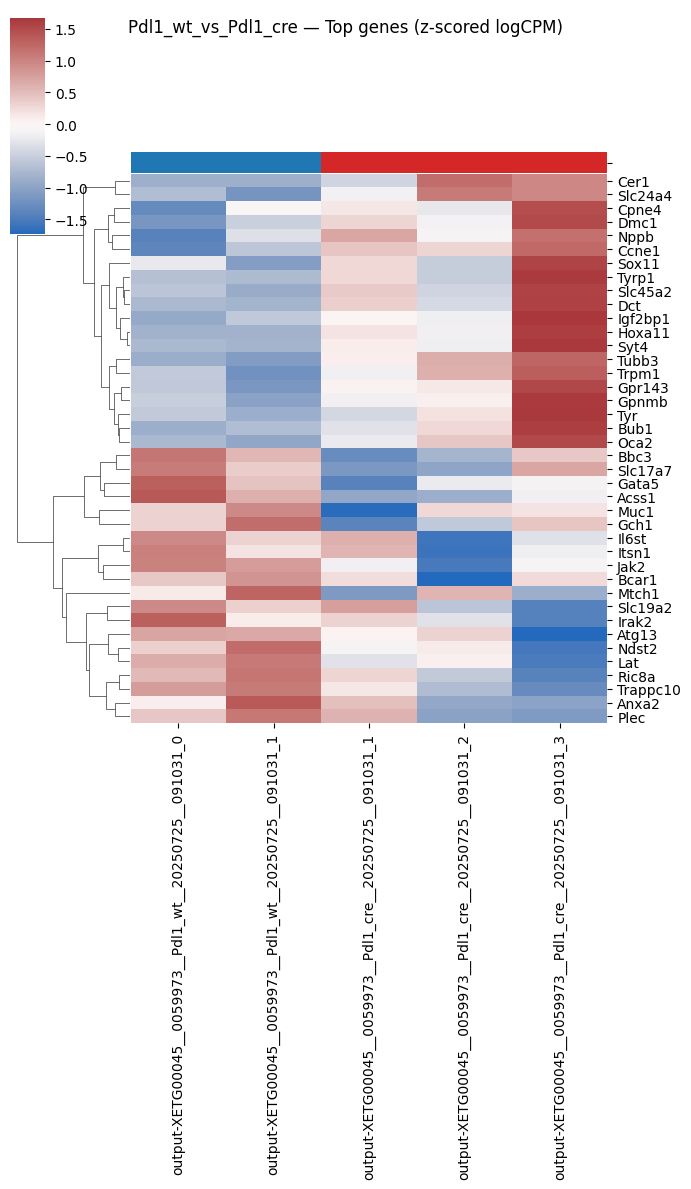

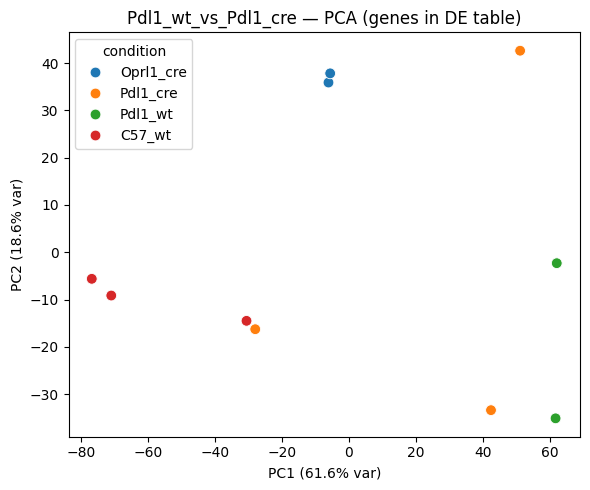

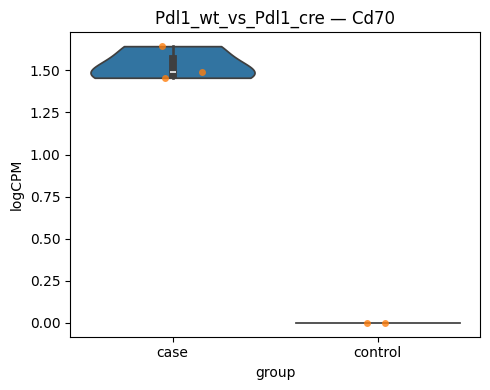

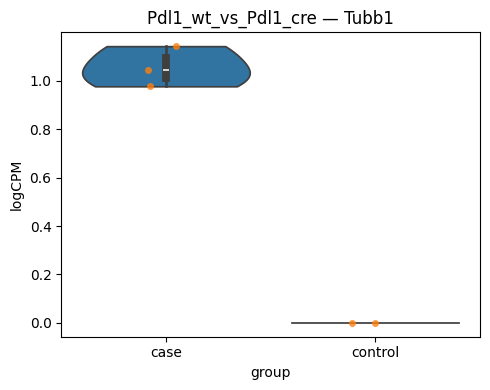

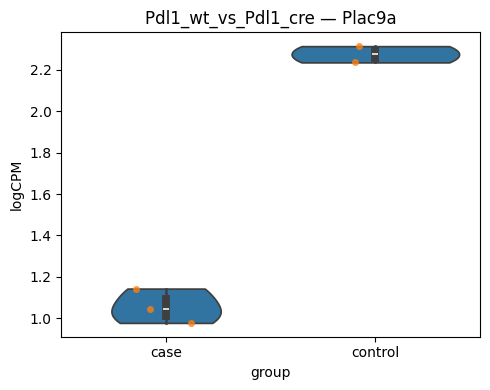

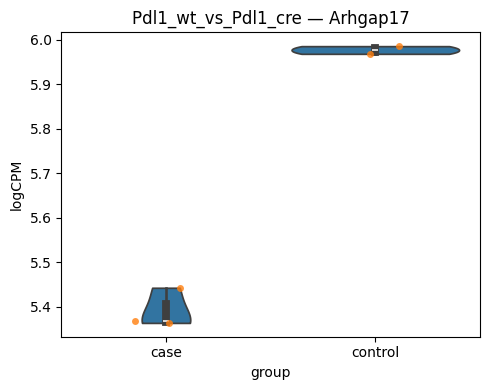

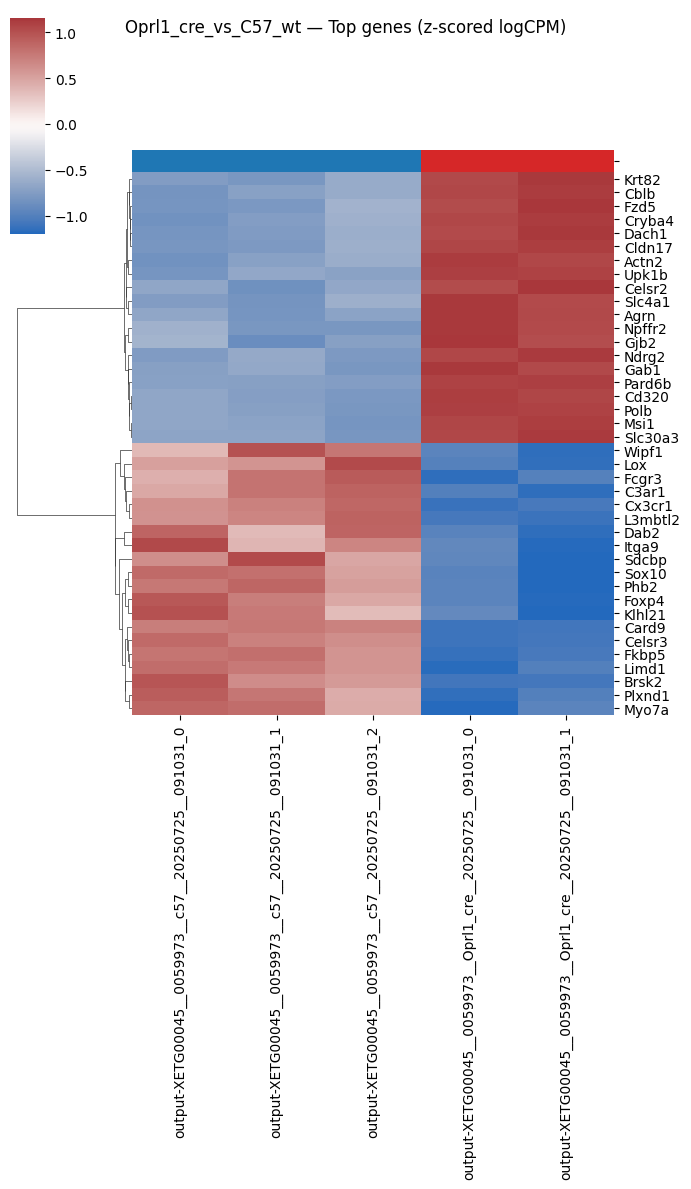

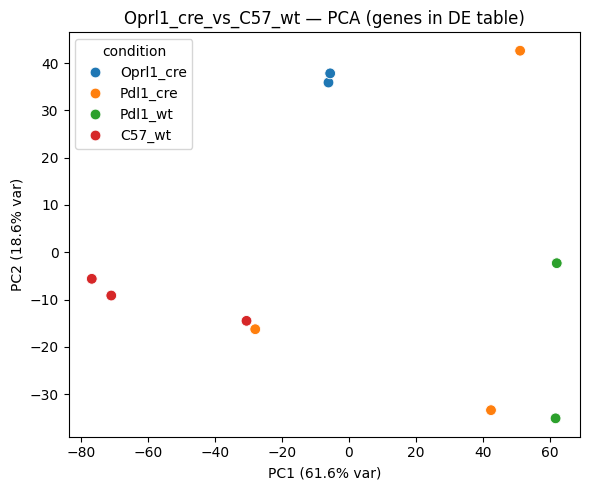

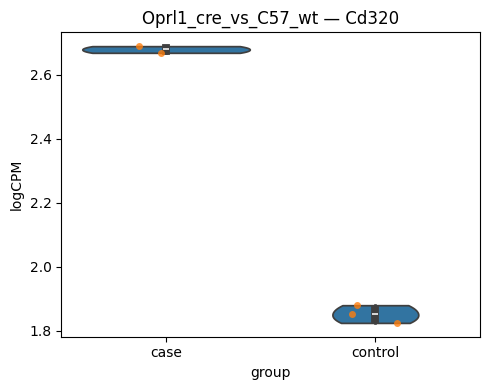

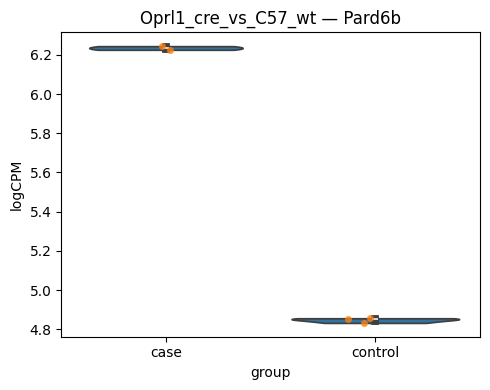

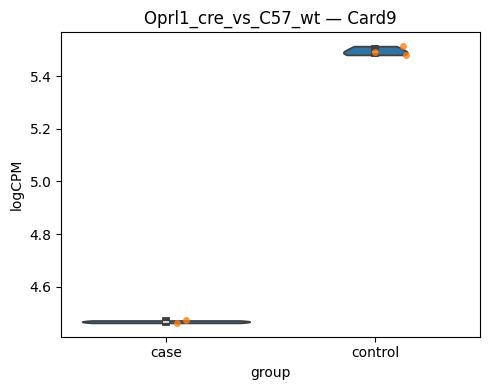

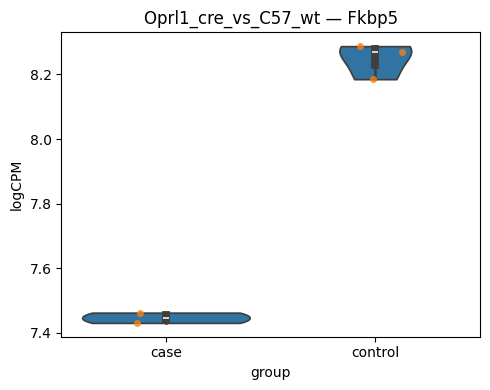

In [23]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------- CONFIG ----------
FDR_THR  = 1
LFC_THR  = 0.5
TOP_N    = 20
FIGSIZE  = (6,5)

def _sig_mask(df, fdr_thr=FDR_THR, lfc_thr=LFC_THR):
    return (df["padj"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

# ---------- VOLCANO ----------
def plot_volcano(de, title="", fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, annotate=True):
    df = de.copy()
    # Handle filtered genes (padj NaN) by setting for plotting only
    df["padj_plot"] = df["padj"].fillna(1.0)
    df["neglog10_padj"] = -np.log10(df["padj_plot"].clip(lower=1e-300))

    sig = (df["padj_plot"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig, "log2fc"], df.loc[~sig, "neglog10_padj"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig,  "log2fc"], df.loc[sig,  "neglog10_padj"], s=10, alpha=0.85)

    plt.axvline(+lfc_thr, ls="--", lw=1, color="grey")
    plt.axvline(-lfc_thr, ls="--", lw=1, color="grey")
    plt.axhline(-np.log10(fdr_thr), ls="--", lw=1, color="grey")

    plt.xlabel("log2FC (case vs control)")
    plt.ylabel("-log10(FDR)")
    plt.title(title or "Volcano")

    if annotate:
        # label significant if any; else label top_n by raw p
        if sig.any():
            lab = df[sig].nsmallest(top_n, "padj_plot")
        else:
            lab = df.nsmallest(top_n, "pval")
        for g, r in lab.iterrows():
            plt.text(r["log2fc"], r["neglog10_padj"], g, fontsize=7, ha="left", va="bottom", alpha=0.8)

    plt.tight_layout()
    plt.show()

# ---------- MA ----------
def plot_ma(de, title="MA"):
    df = de.copy()
    df["A"] = (df["mean_logCPM_case"] + df["mean_logCPM_ctrl"]) / 2.0
    sig = _sig_mask(df)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig,"A"], df.loc[~sig,"log2fc"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig, "A"], df.loc[sig, "log2fc"], s=10, alpha=0.85)
    plt.axhline(0, ls="--", lw=1, color="grey")
    plt.xlabel("Mean logCPM")
    plt.ylabel("log2FC (case vs control)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- HEATMAP (top DE genes) ----------
def plot_heatmap_top(de, logcpm_mat, sample_meta, case_conditions, ctrl_conditions,
                     top_n=TOP_N, title="Top DE genes (z-scored logCPM)"):
    df = de.copy()
    tested = df[~df["padj"].isna()]  # only genes actually tested

    if tested.empty:
        print("[info] No tested genes to display.")
        return

    # Prefer significant genes; else fallback to best by raw p
    candidates = tested[_sig_mask(tested)]
    if candidates.empty:
        candidates = tested.nsmallest(2*top_n, "pval")  # symmetric-ish size
    else:
        # take top_n up + top_n down by FDR then |LFC|
        up = candidates[candidates["log2fc"]>0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        dn = candidates[candidates["log2fc"]<0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        candidates = pd.concat([up, dn])

    genes = candidates.index.tolist()

    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()
    cols = ctrl_cols + case_cols  # controls first, then cases

    M = logcpm_mat.loc[genes, cols]
    Z = (M - M.mean(axis=1).values[:,None]) / (M.std(axis=1).values[:,None] + 1e-9)

    # condition color bar
    col_colors = pd.Series(index=cols, dtype="object")
    for c in ctrl_cols: col_colors[c] = "tab:blue"
    for c in case_cols: col_colors[c] = "tab:red"

    g = sns.clustermap(Z, row_cluster=True, col_cluster=False, cmap="vlag",
                       col_colors=col_colors[cols], figsize=(7,12))
    g.fig.suptitle(title)
    plt.show()

# ---------- PCA (samples) ----------
def plot_sample_pca(logcpm_mat, sample_meta, title="PCA (samples)"):
    X = logcpm_mat.T  # samples × genes
    Xc = X - X.mean(axis=0)
    pca = PCA(n_components=2, random_state=0).fit(Xc)
    PCs = pca.transform(Xc)
    dfp = pd.DataFrame(PCs, index=X.index, columns=["PC1","PC2"]).reset_index().rename(columns={"index":"group_key"})
    dfp = dfp.merge(sample_meta[["group_key","condition"]], on="group_key", how="left")

    plt.figure(figsize=FIGSIZE)
    sns.scatterplot(data=dfp, x="PC1", y="PC2", hue="condition", s=60)
    ve = pca.explained_variance_ratio_ * 100
    plt.xlabel(f"PC1 ({ve[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({ve[1]:.1f}% var)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Per-gene violin ----------
def plot_gene_violin(gene, logcpm_mat, sample_meta, case_conditions, ctrl_conditions, title=None):
    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()

    data = []
    for c in case_cols:
        data.append({"group":"case", "value": logcpm_mat.at[gene, c], "sample": c})
    for c in ctrl_cols:
        data.append({"group":"control", "value": logcpm_mat.at[gene, c], "sample": c})
    df = pd.DataFrame(data)

    plt.figure(figsize=(5,4))
    sns.violinplot(data=df, x="group", y="value", inner="box", cut=0)
    sns.stripplot(data=df, x="group", y="value", alpha=0.8, jitter=0.15)
    plt.ylabel("logCPM")
    plt.title(title or gene)
    plt.tight_layout()
    plt.show()

# ---------- Driver to render a full panel for ONE comparison ----------
def visualize_comparison(name, results, sample_meta, logcpm_mat, comparisons,
                         fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, show_example_violins=True):
    de = results[name]
    case_conds = comparisons[name]["case"]
    ctrl_conds = comparisons[name]["control"]

    # Volcano / MA
    #plot_volcano(de, title=f"{name} — Volcano", fdr_thr=fdr_thr, lfc_thr=lfc_thr, top_n=top_n)
    #plot_ma(de, title=f"{name} — MA")

    # Heatmap (top genes)
    plot_heatmap_top(de, logcpm_mat, sample_meta, case_conds, ctrl_conds,
                     top_n=top_n, title=f"{name} — Top genes (z-scored logCPM)")

    # PCA
    plot_sample_pca(logcpm_mat.loc[de.index], sample_meta, title=f"{name} — PCA (genes in DE table)")

    # Example violins
    if show_example_violins:
        tested = de[~de["padj"].isna()]
        if tested.empty:
            return
        sig = tested[_sig_mask(tested, fdr_thr, lfc_thr)]
        if sig.empty:
            genes_to_show = tested.nsmallest(3, "pval").index.tolist()
        else:
            genes_to_show = pd.concat([
                sig[sig["log2fc"]>0].head(2),
                sig[sig["log2fc"]<0].head(2)
            ]).index.unique().tolist()
        for g in genes_to_show:
            plot_gene_violin(g, logcpm_mat, sample_meta, case_conds, ctrl_conds, title=f"{name} — {g}")

# ---------- Usage ----------
# Single comparison:
# visualize_comparison("Pdl1_wt+C57_vs_Pdl1_cre", results, sample_meta, logcpm_mat, comparisons)

# Or loop all:
for comp_name in comparisons:
     visualize_comparison(comp_name, results, sample_meta, logcpm_mat, comparisons)

## Quick look at DGE using built in scanpy funcitonality 

In [24]:
# Run DE between groups in adata.obs["condition"]
sc.tl.rank_genes_groups(
    ad,
    groupby="condition",          # column in .obs
    method="t-test",              # or "wilcoxon" / "logreg"
    reference="control_group"     # pick which group to compare against
)

# Inspect results
sc.pl.rank_genes_groups(ad, n_genes=20, sharey=False, ncols= 2)

ValueError: reference = control_group needs to be one of groupby = ['Oprl1_cre', 'Pdl1_cre', 'Pdl1_wt', 'C57_wt'].

## Running DGE using built in scanpy functionality (non bulk)

In [ ]:
ad.X = ad.layers['transformed'].copy()


=== Pdl1_wt+C57_vs_Pdl1_cre ===
     gene  logfoldchange           pval       pval_adj
0    Gja1       2.397503   0.000000e+00   0.000000e+00
1     Dsp       1.553611   0.000000e+00   0.000000e+00
2   Krt28       5.479563   0.000000e+00   0.000000e+00
3   Krt71       5.037430   0.000000e+00   0.000000e+00
4     Jup       1.385665   0.000000e+00   0.000000e+00
5    Evpl       1.963276   0.000000e+00   0.000000e+00
6  Pinlyp       3.159889   0.000000e+00   0.000000e+00
7    Crym       6.329122   0.000000e+00   0.000000e+00
8   Fgfr3       1.736825  1.924264e-269  1.030253e-268
9    Egr3       1.678635  6.362383e-266  3.388307e-265


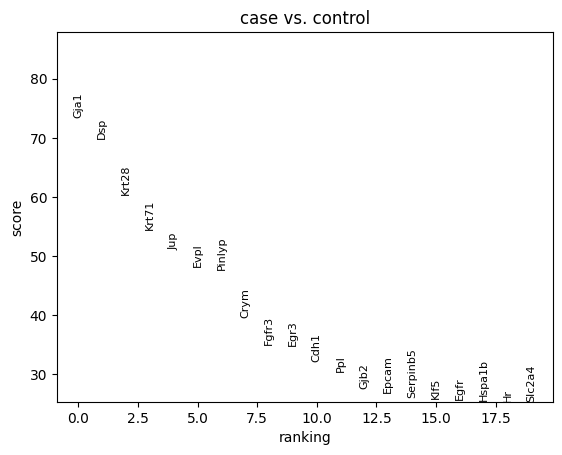


=== Pdl1_wt_vs_Pdl1_cre ===
        gene  logfoldchange           pval       pval_adj
0      Krt28       4.912403   0.000000e+00   0.000000e+00
1       Gja1       1.359054  7.563884e-272  1.893240e-268
2      Krt71       4.138864  7.836570e-265  1.307662e-261
3       Cct3       1.194675  7.442803e-232  9.314668e-229
4      Hspa5       0.812950  6.530910e-194  6.538747e-191
5      Ywhae       0.797056  6.781269e-188  5.657839e-185
6  Hist2h2bb       1.705610  2.180813e-183  1.559593e-180
7     Ctnnb1       0.751463  4.406810e-161  2.757561e-158
8       Rab7       0.540330  1.693154e-157  9.417698e-155
9      Gpnmb       2.341161  2.694620e-157  1.348927e-154


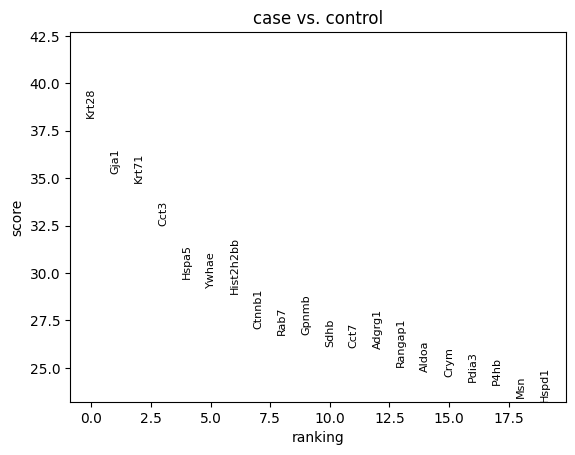


=== Oprl1_cre_vs_C57_wt ===
     gene  logfoldchange           pval       pval_adj
0   Krt71       5.568974   0.000000e+00   0.000000e+00
1   Krt28       5.591274   0.000000e+00   0.000000e+00
2    Gja1       2.519449   0.000000e+00   0.000000e+00
3     Dsp       1.507485   0.000000e+00   0.000000e+00
4    Gjb2       3.598141   0.000000e+00   0.000000e+00
5     Jup       1.347086   0.000000e+00   0.000000e+00
6    Xist       5.210833   0.000000e+00   0.000000e+00
7    Gbp2       2.097808   0.000000e+00   0.000000e+00
8  Pinlyp       4.784083   0.000000e+00   0.000000e+00
9    Crym       6.243680  3.492100e-305  2.660799e-304


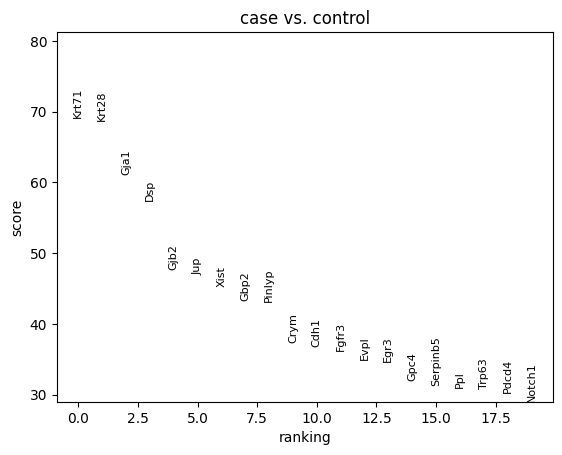

In [ ]:
import scanpy as sc
import pandas as pd

# Your dictionary

results_scanpy = {}

for name, spec in comparisons.items():
    case_conditions = spec["case"]
    ctrl_conditions = spec["control"]

    # Make a temporary grouping column in .obs
    ad.obs["group_DE"] = "rest"
    ad.obs.loc[ad.obs["condition"].isin(case_conditions), "group_DE"] = "case"
    ad.obs.loc[ad.obs["condition"].isin(ctrl_conditions), "group_DE"] = "control"

    # Subset only case + control cells
    ad_sub = ad[ad.obs["group_DE"].isin(["case","control"])].copy()

    # Run DE
    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="group_DE",
        method="wilcoxon",      # or "t-test"
        reference="control"     # always compare case vs control
    )

    # Save results to a tidy DataFrame
    de_res = ad_sub.uns["rank_genes_groups"]
    case_group = "case"

    df = pd.DataFrame({
        "gene": de_res["names"][case_group],
        "logfoldchange": de_res["logfoldchanges"][case_group],
        "pval": de_res["pvals"][case_group],
        "pval_adj": de_res["pvals_adj"][case_group],
    })
    results_scanpy[name] = df

    print(f"\n=== {name} ===")
    print(df.head(10))

    # Quick plot for top genes
    sc.pl.rank_genes_groups(ad_sub, n_genes=20, sharey=False, ncols=2, title=name)

In [ ]:
combined_scanpy = pd.concat(results_scanpy, names=["comparison"])
combined_scanpy = combined_scanpy.reset_index(level="comparison").reset_index(drop=True)

## Export data for customer

In [ ]:
combined_scanpy.to_csv('../../results/differential-gene-expression/tumor_non_pseudobulk_comparision.csv')

In [ ]:
combined_scanpy[combined_scanpy.pval < 0.05].sort_values(by = 'logfoldchange', ascending = False).head(50)

,comparison,gene,logfoldchange,pval,pval_adj
10327,Oprl1_cre_vs_C57_wt,Krt40,9.570565,2.838642e-02,4.634782e-02
10308,Oprl1_cre_vs_C57_wt,Cps1,8.245816,1.283045e-02,2.133861e-02
10192,Oprl1_cre_vs_C57_wt,Slc4a1,6.422040,3.821844e-08,7.344395e-08
10098,Oprl1_cre_vs_C57_wt,Ly6g6d,6.390175,3.511624e-36,8.873897e-36
7,Pdl1_wt+C57_vs_Pdl1_cre,Crym,6.329122,0.000000e+00,0.000000e+00
10226,Oprl1_cre_vs_C57_wt,Krt82,6.256153,5.493120e-06,1.013585e-05
10104,Oprl1_cre_vs_C57_wt,Cryba4,6.254338,5.872906e-32,1.442579e-31
10021,Oprl1_cre_vs_C57_wt,Crym,6.243680,3.492100e-305,2.660799e-304
63,Pdl1_wt+C57_vs_Pdl1_cre,Cryba4,6.213883,6.399576e-25,1.436604e-24
5478,Pdl1_wt_vs_Pdl1_cre,Cryba4,6.013379,2.236657e-10,2.234871e-09


---
# Per-cell-type volcano plots (Q7)
Loads the CyteType-annotated dataset and runs pseudobulk DGE separately for each cell type,
generating a labelled volcano plot per cell type per comparison.

In [ ]:
# Q7: Per-cell-type volcano plots
# Load annotated data and attach condition labels
import scanpy as sc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

ad_ann = sc.read_h5ad('../../data/talbot_xenium_tumor_annotated.h5ad')

file_to_condition = {
    'output-XETG00045__0059973__Pdl1_wt__20250725__091031':  'Pdl1_wt',
    'output-XETG00045__0059973__c57__20250725__091031':      'C57_wt',
    'output-XETG00045__0059973__Pdl1_cre__20250725__091031': 'Pdl1_cre',
    'output-XETG00045__0059973__Oprl1_cre__20250725__091031':'Oprl1_cre',
    'output-XETG00045__0059973__Oprl1_wt__20250725__091031': 'Oprl1_wt',
}
ad_ann.obs['condition'] = ad_ann.obs['sample___'].map(file_to_condition)

comparisons_ct = {
    'Pdl1_wt+C57_vs_Pdl1_cre': {'case': ['Pdl1_cre'],    'control': ['Pdl1_wt', 'C57_wt']},
    'Pdl1_wt_vs_Pdl1_cre':     {'case': ['Pdl1_cre'],    'control': ['Pdl1_wt']},
    'Oprl1_cre_vs_C57_wt':     {'case': ['Oprl1_cre'],   'control': ['C57_wt']},
}

CELLTYPE_COL = 'cytetype_annotation_leiden_4'
COND_COL_CT  = 'condition'
SAMPLE_COL_CT = 'sample_id'
MIN_CELLS_PER_SAMPLE = 5   # minimum cells per cell-type per sample for pseudobulk
MIN_SAMPLES = 2            # require at least this many samples per arm
MIN_TOTAL_COUNTS = 10
PRIOR_COUNT = 1.0
FDR_THR_CT = 0.05
LFC_THR_CT = 0.5
TOP_N_CT = 15

print(f'Loaded annotated data: {ad_ann.shape}')
print(f'Cell types: {ad_ann.obs[CELLTYPE_COL].nunique()}')


In [ ]:
# Helper: pseudobulk + DE for one cell-type slice
def pseudobulk_de_celltype(adata_ct, case_conds, ctrl_conds,
                           cond_col=COND_COL_CT, sample_col=SAMPLE_COL_CT):
    """Returns a DE DataFrame (indexed by gene) or None if not enough replicates."""
    X = adata_ct.layers['counts'] if 'counts' in adata_ct.layers else adata_ct.X
    if sparse.issparse(X):
        X = X.tocsr()
    genes = adata_ct.var_names

    obs = adata_ct.obs[[sample_col, cond_col]].copy()
    obs = obs[obs[cond_col].isin(case_conds + ctrl_conds)]
    if obs.empty:
        return None

    # Pseudobulk per sample
    pb_dict = {}
    for sid, grp in obs.groupby(sample_col):
        idx = grp.index
        if len(idx) < MIN_CELLS_PER_SAMPLE:
            continue
        xi = X[adata_ct.obs_names.get_indexer(idx)]
        pb_dict[sid] = np.asarray(xi.sum(axis=0)).ravel() if sparse.issparse(xi) else xi.sum(axis=0).ravel()
    if not pb_dict:
        return None

    pb = pd.DataFrame(pb_dict, index=genes)  # genes x samples
    pb = pb.loc[pb.sum(axis=1) >= MIN_TOTAL_COUNTS]
    if pb.empty:
        return None

    # logCPM
    lib = pb.sum(axis=0).values.astype(float)
    lcpm = pd.DataFrame(
        np.log2((pb.values * 1e6) / np.maximum(lib, 1) + PRIOR_COUNT),
        index=pb.index, columns=pb.columns
    )

    # condition per sample
    cond_map = obs.drop_duplicates(sample_col).set_index(sample_col)[cond_col].to_dict()
    case_cols = [s for s in pb.columns if cond_map.get(s) in case_conds]
    ctrl_cols = [s for s in pb.columns if cond_map.get(s) in ctrl_conds]

    if len(case_cols) < MIN_SAMPLES or len(ctrl_cols) < MIN_SAMPLES:
        return None

    Xc = lcpm[case_cols].values
    Xn = lcpm[ctrl_cols].values
    log2fc = Xc.mean(axis=1) - Xn.mean(axis=1)
    t, pvals = stats.ttest_ind(Xc, Xn, equal_var=False, axis=1, nan_policy='omit')
    pvals = np.clip(np.where(np.isfinite(pvals), pvals, 1.0), np.finfo(float).tiny, 1.0)
    padj = multipletests(pvals, method='fdr_bh')[1]

    return pd.DataFrame({'log2fc': log2fc, 'pval': pvals, 'padj': padj},
                        index=lcpm.index).sort_values('padj')


def volcano_celltype(de, title, fdr_thr=FDR_THR_CT, lfc_thr=LFC_THR_CT, top_n=TOP_N_CT):
    df = de.copy()
    df['neg_log10_padj'] = -np.log10(df['padj'].clip(lower=1e-300))
    sig = (df['padj'] <= fdr_thr) & (df['log2fc'].abs() >= lfc_thr)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df.loc[~sig, 'log2fc'], df.loc[~sig, 'neg_log10_padj'],
               s=6, alpha=0.35, color='#aaaaaa', label='n.s.')
    ax.scatter(df.loc[sig & (df['log2fc'] > 0), 'log2fc'],
               df.loc[sig & (df['log2fc'] > 0), 'neg_log10_padj'],
               s=8, alpha=0.8, color='#e05c5c', label='up')
    ax.scatter(df.loc[sig & (df['log2fc'] < 0), 'log2fc'],
               df.loc[sig & (df['log2fc'] < 0), 'neg_log10_padj'],
               s=8, alpha=0.8, color='#5c8ae0', label='down')

    ax.axvline(+lfc_thr, ls='--', lw=0.8, color='grey')
    ax.axvline(-lfc_thr, ls='--', lw=0.8, color='grey')
    ax.axhline(-np.log10(fdr_thr), ls='--', lw=0.8, color='grey')

    # Label top hits
    label_pool = df[sig] if sig.any() else df.nsmallest(top_n, 'pval')
    label_genes = label_pool.nsmallest(top_n, 'padj')
    for gene, row in label_genes.iterrows():
        ax.text(row['log2fc'], row['neg_log10_padj'], gene,
                fontsize=6, ha='left', va='bottom', alpha=0.8)

    n_up = int((sig & (df['log2fc'] > 0)).sum())
    n_dn = int((sig & (df['log2fc'] < 0)).sum())
    ax.set_xlabel('log2FC (case vs control)')
    ax.set_ylabel('-log10(FDR)')
    ax.set_title(f'{title}\n(up={n_up}, down={n_dn})', fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    plt.tight_layout()
    plt.show()


In [ ]:
# Run per-cell-type volcano plots for each comparison
cell_types = ad_ann.obs[CELLTYPE_COL].cat.categories.tolist()
print(f'Running per-cell-type DGE for {len(cell_types)} cell types x {len(comparisons_ct)} comparisons...\n')

for comp_name, spec in comparisons_ct.items():
    case_conds  = spec['case']
    ctrl_conds  = spec['control']
    print(f'\n{'='*60}')
    print(f'Comparison: {comp_name}')
    print(f'  case={case_conds}  control={ctrl_conds}')
    print(f'{'='*60}')

    plotted = 0
    for ct in cell_types:
        adata_ct = ad_ann[ad_ann.obs[CELLTYPE_COL] == ct].copy()
        if len(adata_ct) < MIN_CELLS_PER_SAMPLE * MIN_SAMPLES:
            continue

        de = pseudobulk_de_celltype(adata_ct, case_conds, ctrl_conds)
        if de is None or de.empty:
            continue

        # Only plot if there are results
        safe_ct = ct[:60]  # truncate long names for title
        volcano_celltype(de, title=f'{comp_name}\n{safe_ct}')
        plotted += 1

    print(f'  Plotted {plotted} cell types (skipped those with insufficient replicates)')
